Importation des données

In [2]:
import pandas as pd

df = pd.read_csv(
    "C:/Users/fredm/Desktop/projet_IA/besoin_client_1/data/export_IA.csv",
    sep=",",
    encoding="utf-8"
)

C:\Users\fredm\AppData\Local\Temp\ipykernel_35416\3046079018.py:3: DtypeWarning: Columns (6,10,11,12,13,14,16,19,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [3]:
df.columns

Index(['contact_operateur', 'nom_enseigne', 'id_station_itinerance',
       'nom_station', 'implantation_station', 'adresse_station',
       'code_insee_commune', 'nbre_pdc', 'id_pdc_itinerance',
       'puissance_nominale', 'prise_type_ef', 'prise_type_2',
       'prise_type_combo_ccs', 'prise_type_chademo', 'prise_type_autre',
       'gratuit', 'paiement_acte', 'tarification', 'condition_acces',
       'reservation', 'horaires', 'accessibilite_pmr', 'station_deux_roues',
       'date_mise_en_service', 'consolidated_longitude',
       'consolidated_latitude', 'consolidated_commune',
       'consolidated_is_lon_lat_correct',
       'consolidated_is_code_insee_verified',
       'consolidated_is_code_insee_modified', 'annee_mise_en_service',
       'mois_mise_en_service', 'tarif_level', 'puissance_nominale_level'],
      dtype='object')

Nettoyage des données

In [ ]:
df = df[
    (df["consolidated_latitude"].notna()) &
    (df["consolidated_longitude"].notna())
]

In [4]:
colonnes = [
    "consolidated_latitude",
    "consolidated_longitude",
    "implantation_station",
    "puissance_nominale"
]

df = df[colonnes]

df = df.dropna()

print(df.shape)
print(df.head())

(182496, 4)
   consolidated_latitude  consolidated_longitude  \
0              43.419591                3.407609   
1              48.832678                2.493570   
2              41.908579                8.657888   
3              43.476584                5.476711   
4              43.329200                5.143766   

           implantation_station  puissance_nominale  
0  Parking privé à usage public                22.0  
1  Parking privé à usage public                22.0  
2  Parking privé à usage public                22.0  
3  Parking privé à usage public                22.0  
4  Parking privé à usage public                36.0  


In [5]:
print(df.info())

print(df.isnull().sum())

print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182496 entries, 0 to 182495
Data columns (total 4 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   consolidated_latitude   182496 non-null  float64
 1   consolidated_longitude  182496 non-null  float64
 2   implantation_station    182496 non-null  object 
 3   puissance_nominale      182496 non-null  float64
dtypes: float64(3), object(1)
memory usage: 5.6+ MB
None
consolidated_latitude     0
consolidated_longitude    0
implantation_station      0
puissance_nominale        0
dtype: int64
       consolidated_latitude  consolidated_longitude  puissance_nominale
count          182496.000000           182496.000000       182496.000000
mean               46.718943                2.807992           70.771591
std                 4.226082                4.636753           92.956418
min               -22.246100             -149.905377            0.000100
25%                

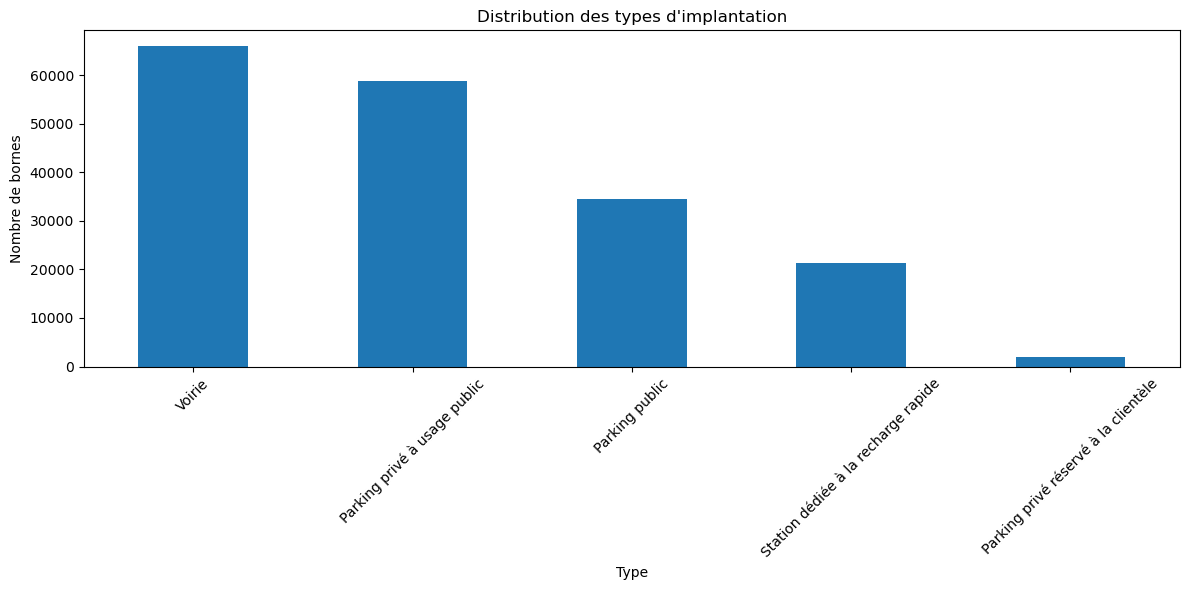

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

df["implantation_station"].value_counts().plot(
    kind="bar"
)

plt.title("Distribution des types d'implantation")
plt.xlabel("Type")
plt.ylabel("Nombre de bornes")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

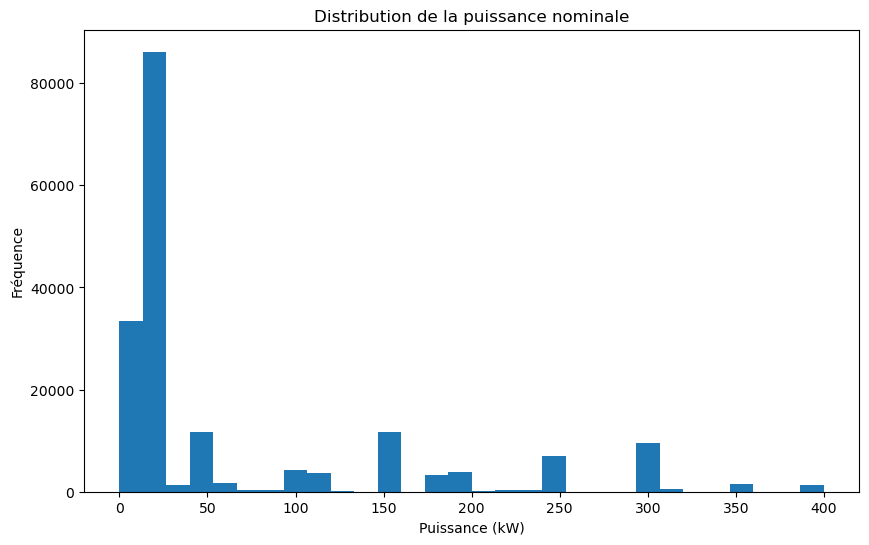

In [7]:
plt.figure(figsize=(10,6))

plt.hist(
    df["puissance_nominale"],
    bins=30
)

plt.title("Distribution de la puissance nominale")
plt.xlabel("Puissance (kW)")
plt.ylabel("Fréquence")

plt.show()